# Day 1 — Foundations: Dataset Landscape & Bias-Variance Demo
### 🔑 SOLUTION VERSION — all exercises completed

Companion notebook to the Day 1 lecture. Two independent parts:

**Part 1** — compare the public fraud-dataset landscape referenced in the slides (no downloads needed —
we work from published dataset statistics), plus an optional live download of the **ULB Credit Card Fraud**
dataset to verify those numbers against the real data.

**Part 2** — a from-scratch bias-variance demonstration: fit polynomials of increasing complexity to noisy
data and *see* underfitting, overfitting, and the sweet spot, connecting back to the dartboard picture
from the lecture.

This is the instructor/solution copy — every `# TODO` cell is filled in, and reflection questions include
a model answer. Use it to check your own work or to run the class demo live.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 4.5)

## Part 1 — The public fraud-dataset landscape

These figures come from the dataset documentation and papers cited in the Day 1 slides. We're not
downloading the raw data here — the point is to build intuition for *how differently imbalanced*
fraud problems are, before we touch a single classifier tomorrow.

In [2]:
datasets = pd.DataFrame([
    {"dataset": "ULB Credit Card (Kaggle)", "domain": "card-present/CNP txns", "n_rows": 284_807, "fraud_rate_pct": 0.172, "source": "Kaggle mlg-ulb/creditcardfraud"},
    {"dataset": "PaySim (simulated)",       "domain": "mobile money",          "n_rows": 6_362_620, "fraud_rate_pct": 0.130, "source": "Lopez-Rojas (2017)"},
    {"dataset": "IEEE-CIS Fraud Detection", "domain": "e-commerce",            "n_rows": 590_540,  "fraud_rate_pct": 3.500, "source": "Kaggle ieee-fraud-detection"},
    {"dataset": "ACFE occupational (case-level)", "domain": "occupational fraud", "n_rows": 1_921, "fraud_rate_pct": 5.000, "source": "ACFE Report to the Nations 2024 (case mix, not txn-level)"},
])
datasets["n_fraud_examples"] = None #TODO 

,dataset,domain,n_rows,fraud_rate_pct,source,n_fraud_examples
0,ULB Credit Card (Kaggle),card-present/CNP txns,284807,0.172,Kaggle mlg-ulb/creditcardfraud,490
1,PaySim (simulated),mobile money,6362620,0.130,Lopez-Rojas (2017),8271
2,IEEE-CIS Fraud Detection,e-commerce,590540,3.500,Kaggle ieee-fraud-detection,20669
3,ACFE occupational (case-level),occupational fraud,1921,5.000,"ACFE Report to the Nations 2024 (case mix, not...",96


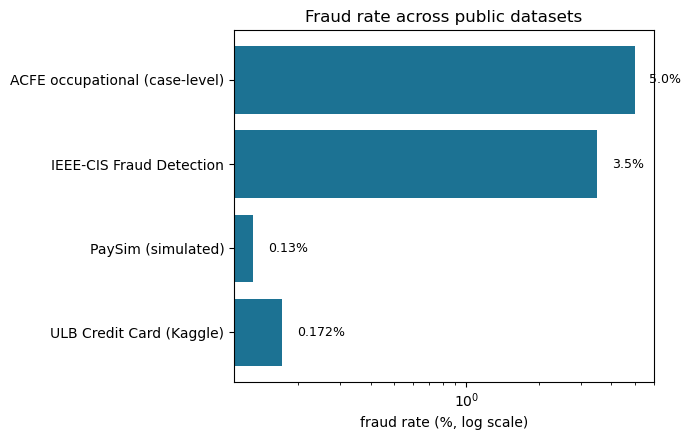

In [3]:
fig, ax = plt.subplots()
ax.barh(datasets["dataset"], datasets["fraud_rate_pct"], color="#1C7293")
ax.set_xscale("log")
ax.set_xlabel("fraud rate (%, log scale)")
ax.set_title("Fraud rate across public datasets")
for i, v in enumerate(datasets["fraud_rate_pct"]):
    ax.text(v * 1.15, i, f"{v}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

### Verify with real data: download the ULB Credit Card Fraud dataset

The table above uses figures **quoted from dataset documentation and papers** (see the `source` column) —
useful for a quick comparison, but worth verifying against the actual file. Below we pull the **ULB Credit
Card Fraud** dataset for real and recompute `n_rows` and `fraud_rate_pct` directly from the data.

It's mirrored on **OpenML**, so no Kaggle account or API key is needed — this should just work as long as
this notebook's environment has internet access.

*(The other three datasets — PaySim, IEEE-CIS, ACFE — are left as quoted figures only in this notebook.
PaySim in particular is Kaggle-only and requires API credentials; see the course's full version of this
notebook if you want that download cell too.)*

In [4]:
import pandas as pd

real_stats = []

# ULB Credit Card Fraud, via OpenML (public, no credentials needed)
# https://scikit-learn.org/stable/api/sklearn.datasets.html
try:
    from sklearn.datasets import fetch_openml

    ulb = fetch_openml(name="creditcard", version=1, as_frame=True, parser="auto")
    ulb_df = ulb.frame
    # the target column is usually called "Class" (1 = fraud, 0 = legitimate)
    fraud_col = "Class" if "Class" in ulb_df.columns else ulb_df.columns[-1]
    n_rows = None #TODO
    fraud_rate = None #TODO
    real_stats.append({"dataset": "ULB Credit Card (Kaggle)", "n_rows_actual": n_rows, "fraud_rate_pct_actual": round(fraud_rate, 3)})
    print(f"ULB Credit Card: {n_rows:,} rows, {fraud_rate:.3f}% fraud (downloaded via OpenML)")
except Exception as e:
    print(f"Could not download ULB Credit Card via OpenML: {e}")
    print("If this is a network/proxy error, try again on a machine with unrestricted internet access.")

# Compare downloaded stats to the quoted figures in `datasets` above
if real_stats:
    comparison = datasets.merge(pd.DataFrame(real_stats), on="dataset", how="inner")
    comparison["fraud_rate_diff_pct"] = (comparison["fraud_rate_pct_actual"] - comparison["fraud_rate_pct"]).round(4)
    print()
    display(comparison[["dataset", "n_rows", "n_rows_actual", "fraud_rate_pct", "fraud_rate_pct_actual", "fraud_rate_diff_pct"]])
else:
    print("\nDataset was not downloaded successfully — nothing to compare yet.")

ULB Credit Card: 284,807 rows, 0.173% fraud (downloaded via OpenML)



,dataset,n_rows,n_rows_actual,fraud_rate_pct,fraud_rate_pct_actual,fraud_rate_diff_pct
0,ULB Credit Card (Kaggle),284807,284807,0.172,0.173,0.001


### TODO 1 — classify each dataset on the imbalance scale

Using the scale from the Day 2 preview (mild 20-40%, moderate 5-20%, strong 0.1-5%, extreme <0.1%),
label each dataset below.

In [5]:

imbalance_labels = {
    "ULB Credit Card (Kaggle)": None,#TODO              
    "PaySim (simulated)": None, #TODO                     
    "IEEE-CIS Fraud Detection": None, #TODO              
    "ACFE occupational (case-level)": None, #TODO         
                                                          }
datasets["imbalance_category"] = datasets["dataset"].map(imbalance_labels)
datasets[["dataset", "fraud_rate_pct", "imbalance_category"]]

,dataset,fraud_rate_pct,imbalance_category
0,ULB Credit Card (Kaggle),0.172,strong
1,PaySim (simulated),0.130,strong
2,IEEE-CIS Fraud Detection,3.500,strong
3,ACFE occupational (case-level),5.000,moderate


### Reflection — Part 1

- Which dataset would you pick for a *first* project, and why? Consider: number of positive examples in
  absolute terms (not just percentage), whether the data is real or simulated, and known caveats
  (e.g. PaySim's potential label leakage, mentioned in the slides).

**Answer:**



## Part 2 — Bias-variance, hands-on

We'll generate noisy data from a known underlying function, then fit polynomials of increasing degree.
Low-degree fits will *underfit* (high bias); very high-degree fits will *overfit* (high variance, chasing
noise). This is the mechanism behind the dartboard picture in the lecture — here it's dials you can turn.

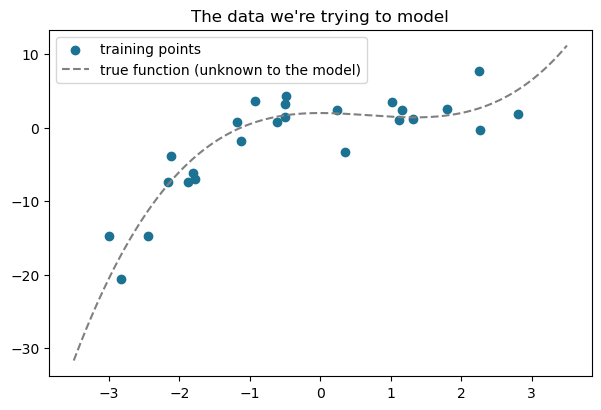

In [6]:
def true_function(x):
    return 0.5 * x**3 - x**2 + 2

def make_dataset(n=30, noise_std=3.0, seed=None):
    rng = np.random.RandomState(seed)
    x = rng.uniform(-3, 3, n)
    y = true_function(x) + rng.normal(0, noise_std, n)
    return x, y

x_train, y_train = make_dataset(n=25, noise_std=3.0, seed=1)
x_test, y_test = make_dataset(n=200, noise_std=3.0, seed=2)

x_grid = np.linspace(-3.5, 3.5, 300)
plt.scatter(x_train, y_train, color="#1C7293", label="training points")
plt.plot(x_grid, true_function(x_grid), color="gray", linestyle="--", label="true function (unknown to the model)")
plt.legend()
plt.title("The data we're trying to model")
plt.show()

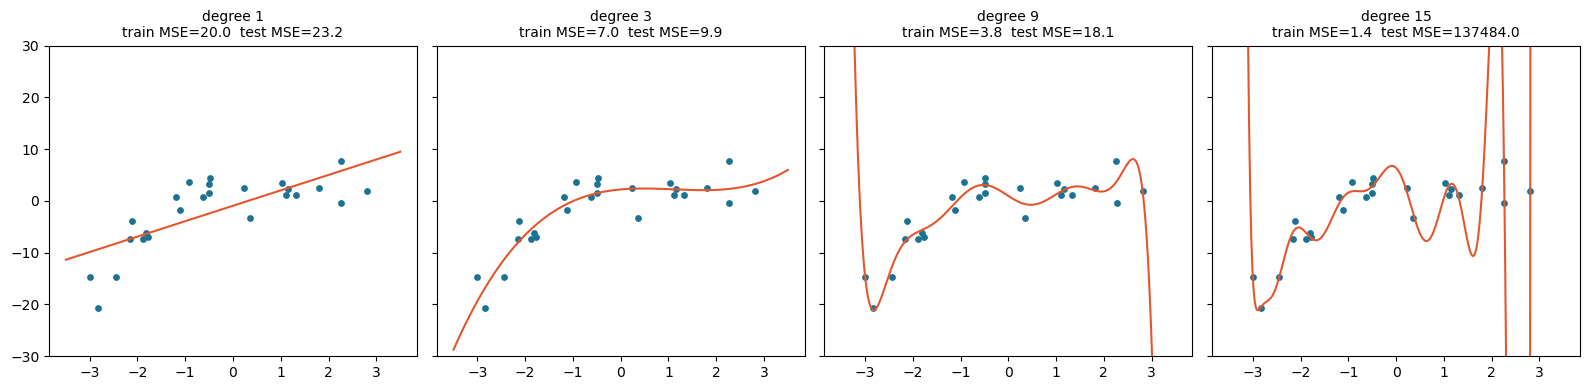

In [7]:
degrees = [1, 3, 9, 15]
fig, axes = plt.subplots(1, len(degrees), figsize=(16, 4), sharey=True)

train_errors, test_errors = [], []
for ax, deg in zip(axes, degrees):
    coeffs = np.polyfit(x_train, y_train, deg)
    poly = np.poly1d(coeffs)

    train_pred = poly(x_train)
    test_pred = poly(x_test)
    train_mse = np.mean((train_pred - y_train) ** 2)
    test_mse = np.mean((test_pred - y_test) ** 2)
    train_errors.append(train_mse)
    test_errors.append(test_mse)

    ax.scatter(x_train, y_train, color="#1C7293", s=15)
    ax.plot(x_grid, poly(x_grid), color="#E4572E")
    ax.set_ylim(-30, 30)
    ax.set_title(f"degree {deg}\ntrain MSE={train_mse:.1f}  test MSE={test_mse:.1f}", fontsize=10)

plt.tight_layout()
plt.show()

### TODO 2 — read the train/test error curve

Fill in the loop below to compute train and test error across a *wide* range of polynomial degrees, then
plot both curves on the same axes.

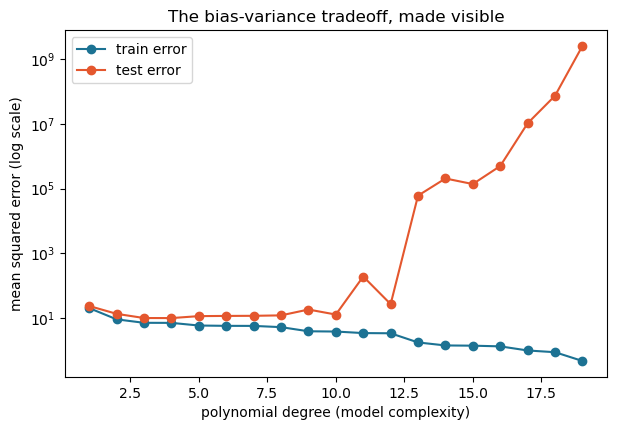

In [8]:
all_degrees = range(1, 20)
train_mses, test_mses = [], []

for deg in all_degrees:
    coeffs = np.polyfit(x_train, y_train, deg)
    poly = np.poly1d(coeffs)
    # TODO: mean squared error on the training set and on the held-out test set
    train_mse = None #TODO
    test_mse = None #TODO
    train_mses.append(train_mse)
    test_mses.append(test_mse)

plt.plot(list(all_degrees), train_mses, marker="o", label="train error", color="#1C7293")
plt.plot(list(all_degrees), test_mses, marker="o", label="test error", color="#E4572E")
plt.yscale("log")
plt.xlabel("polynomial degree (model complexity)")
plt.ylabel("mean squared error (log scale)")
plt.legend()
plt.title("The bias-variance tradeoff, made visible")
plt.show()

### Reflection — Part 2

- Where does the test error hit its minimum? What happens to train error *past* that point, and why
  doesn't that mean the model is still improving?
- Connect this plot back to the dartboard slide: which region of the x-axis is "high bias," and which is
  "high variance"?

**Answer:**

